Understanding Image in matrix


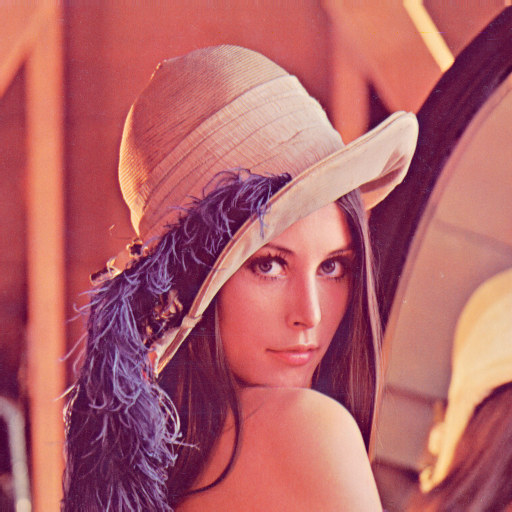

In [ ]:
from PIL import Image
image_colored= Image.open('/content/Lenna_(test_image).png')
display(image_colored)

In [ ]:
print("Image Format :" , image_colored.format)
print("Image Size :" , image_colored.size)
print("Image Mode :" , image_colored.mode)

Image Format : PNG
Image Size : (512, 512)
Image Mode : RGB


In [ ]:
width , height = image_colored.size
channels = len(image_colored.getbands())
print (f"image shape (RGB): ({height},{width},{channels})")
image_size_colored = height * width * channels  # Assuming image_size_colored means total number of color components (pixels * channels)
print(f"image size (RGB):{image_size_colored}")

image shape (RGB): (512,512,3)
image size (RGB):786432


In [ ]:
import numpy as np
image_array_colored=np.array(image_colored)
print("Shape of the image array:",image_array_colored.shape)

Shape of the image array: (512, 512, 3)


Shape of the image array: (512, 512, 3)
[[226 226 223 ... 230 221 200]
 [226 226 223 ... 230 221 200]
 [226 226 223 ... 230 221 200]
 ...
 [ 84  84  92 ... 173 172 177]
 [ 82  82  96 ... 179 181 185]
 [ 82  82  96 ... 179 181 185]]


array([[226, 226, 223, ..., 230, 221, 200],
       [226, 226, 223, ..., 230, 221, 200],
       [226, 226, 223, ..., 230, 221, 200],
       ...,
       [ 84,  84,  92, ..., 173, 172, 177],
       [ 82,  82,  96, ..., 179, 181, 185],
       [ 82,  82,  96, ..., 179, 181, 185]], dtype=uint8)
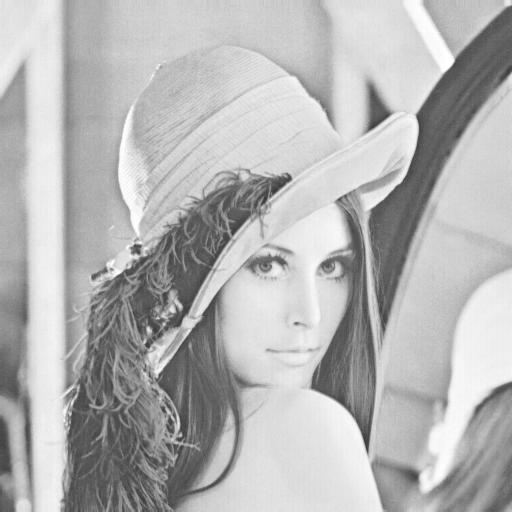

[[137 137 137 ... 148 130  99]
 [137 137 137 ... 148 130  99]
 [137 137 137 ... 148 130  99]
 ...
 [ 18  18  27 ...  73  68  62]
 [ 22  22  32 ...  70  71  74]
 [ 22  22  32 ...  70  71  74]]


array([[137, 137, 137, ..., 148, 130,  99],
       [137, 137, 137, ..., 148, 130,  99],
       [137, 137, 137, ..., 148, 130,  99],
       ...,
       [ 18,  18,  27, ...,  73,  68,  62],
       [ 22,  22,  32, ...,  70,  71,  74],
       [ 22,  22,  32, ...,  70,  71,  74]], dtype=uint8)
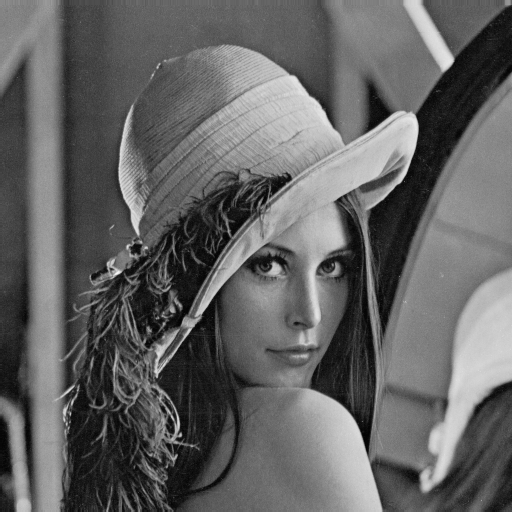

[[125 125 133 ... 122 110  90]
 [125 125 133 ... 122 110  90]
 [125 125 133 ... 122 110  90]
 ...
 [ 60  60  58 ...  84  76  79]
 [ 57  57  62 ...  79  81  81]
 [ 57  57  62 ...  79  81  81]]


array([[125, 125, 133, ..., 122, 110,  90],
       [125, 125, 133, ..., 122, 110,  90],
       [125, 125, 133, ..., 122, 110,  90],
       ...,
       [ 60,  60,  58, ...,  84,  76,  79],
       [ 57,  57,  62, ...,  79,  81,  81],
       [ 57,  57,  62, ...,  79,  81,  81]], dtype=uint8)
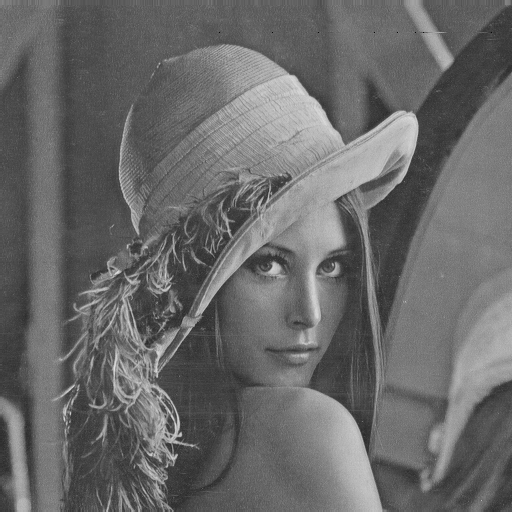

In [ ]:
image_array_colored = np.array(image_colored)
print("Shape of the image array:", image_array_colored.shape)
red_channel = image_array_colored[:, :, 0]
print(red_channel)
display(red_channel)
green_channel = image_array_colored[:, :, 1]
print(green_channel)
display(green_channel)
blue_channel = image_array_colored[:, :, 2] # Corrected index to 2 for blue channel
print(blue_channel)
display(blue_channel)

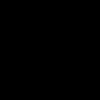

In [ ]:
# Create a NumPy array (Here, we use a dummy array for illustration)
image_array = np.zeros((100, 100, 3), dtype=np.uint8)  # Example: black image
# Convert the NumPy array back to a Pillow Image object
image_from_array = Image.fromarray(image_array)
# Display the image
from IPython.display import display
display(image_from_array)
# Optionally save the image to a file
image_from_array.save("output_image.jpg")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image.open('/content/Lenna_(test_image).png').convert("L")
# Convert to NumPy array
image_array = np.array(image)
# Get image dimensions
height, width = image_array.shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array.reshape(height, width)

In [ ]:
# Compute the mean of each column (feature)
mean = np.mean(data, axis=0)
# Subtract mean to center the data
centered_data = data - mean

In [ ]:
# Compute covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

In [ ]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [ ]:
k = 50  # Choose k principal components
components = eigenvectors[:, :k]

In [ ]:
# Project the data onto the principal components
compressed_data = np.dot(centered_data, components)

In [ ]:
# Reconstruct the image from compressed data
decompressed_data = np.dot(compressed_data, components.T) + mean

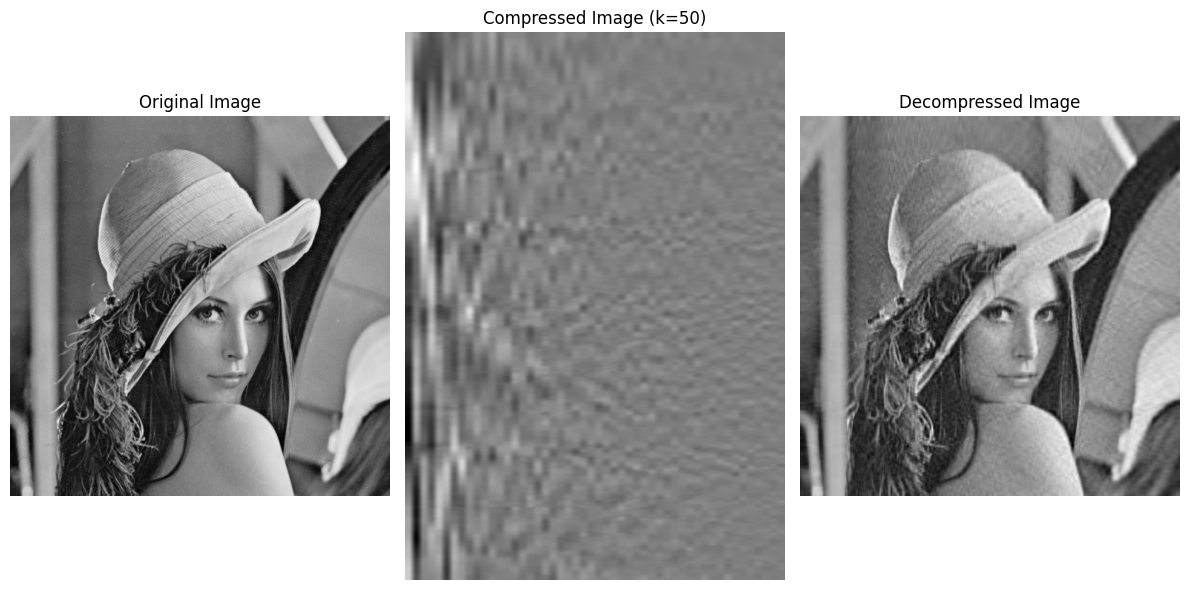

In [ ]:
plt.figure(figsize=(12, 6))
# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
# Compressed Representation
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")
# Decompressed Image
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")
plt.tight_layout()
plt.show()